In [32]:
from scipy.io import loadmat
import numpy as np
import control as ct
import matplotlib.pyplot as plt

In [33]:
dados = loadmat('Pneumático_G4.mat')

print(dados.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Degrau', 'Saida', 't', 'unidade_saida', 'parametros', 'descricao'])


In [34]:
t = dados['t'].squeeze()
entrada = dados['Degrau'].squeeze()
saida = dados['Saida'].squeeze()

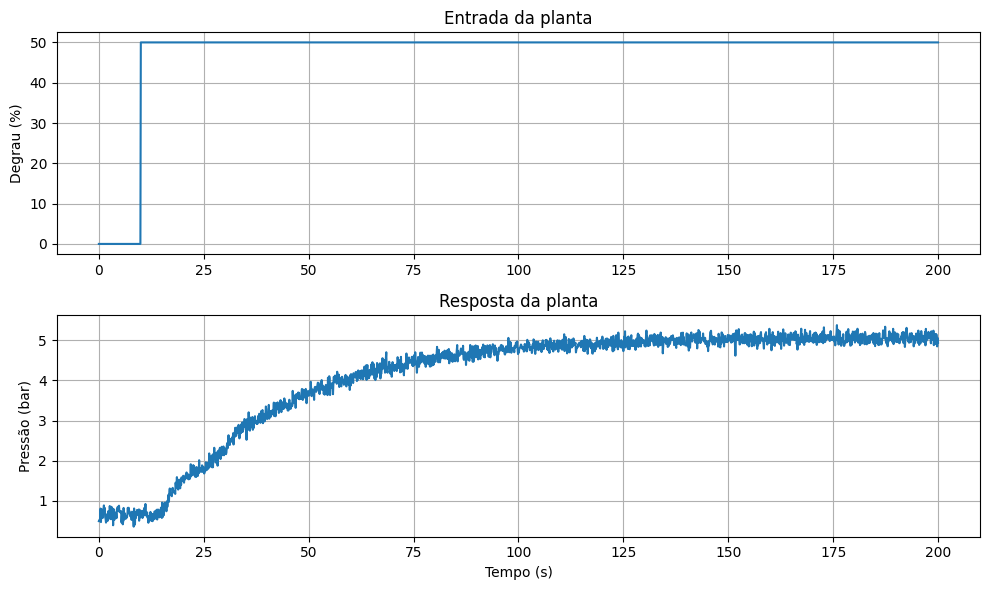

In [35]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, entrada)
plt.grid()
plt.ylabel('Degrau (%)')
plt.title('Entrada da planta')

plt.subplot(2, 1, 2)
plt.plot(t, saida)
plt.grid()
plt.xlabel('Tempo (s)')
plt.ylabel('Pressão (bar)')
plt.title('Resposta da planta')

plt.tight_layout()
plt.show()

### método de identificação de smith

In [36]:
# pegando as médias dos 10 valores iniciais e finais
n = 10
u0 = np.mean(entrada[:n])
uf = np.mean(entrada[-n:])


y0 = np.mean(saida[:n])
yf = np.mean(saida[-n:])

delta_u = uf - u0
delta_y = yf - y0

K = delta_y / delta_u

# Níveis de Smith
y_t1 = y0 + 0.283 * delta_y
y_t2 = y0 + 0.632 * delta_y

t1 = t[np.where(saida >= y_t1)[0][0]]
t2 = t[np.where(saida >= y_t2)[0][0]]

tau = 1.5 * (t2 - t1)
theta = t2 - tau

print(K)
print(tau)
print(theta)

0.08814492968715427
29.700000000000003
12.0


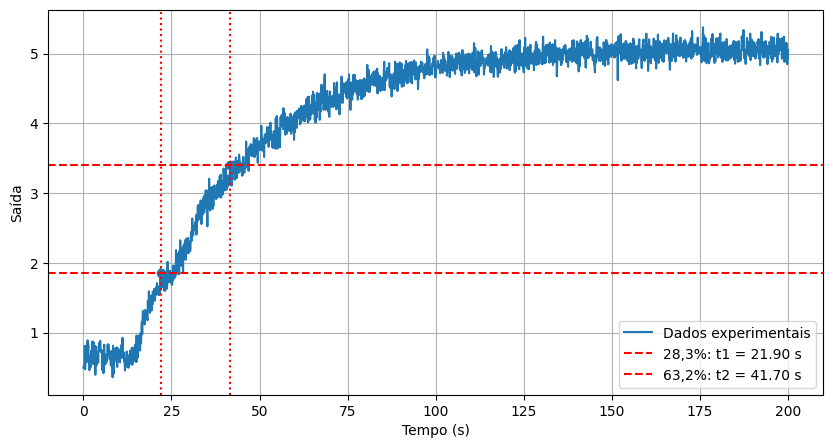

In [37]:
plt.figure(figsize=(10,5))

plt.plot(t, saida, label='Dados experimentais')

plt.axhline(y_t1, linestyle='--',
            label=f'28,3%: t1 = {t1:.2f} s',c='r')

plt.axhline(y_t2, linestyle='--',
            label=f'63,2%: t2 = {t2:.2f} s',c='r')

plt.axvline(t1, linestyle=':',c='r')
plt.axvline(t2, linestyle=':',c='r')

plt.scatter([t1, t2], [y_t1, y_t2])

plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.grid()
plt.legend()
plt.show()

### método de identificação de Sundaresan


In [38]:
# Níveis de Sundaresan
y_t1_sun = y0 + 0.353 * delta_y
y_t2_sun = y0 + 0.853 * delta_y

t1_sun = t[np.where(saida >= y_t1_sun)[0][0]]
t2_sun = t[np.where(saida >= y_t2_sun)[0][0]]

tau_sun = (2/3) * (t2_sun - t1_sun)
theta_sun = 1.3 * t1_sun - 0.29 * t2_sun

print(K)
print(tau_sun)
print(theta_sun)

0.08814492968715427
24.933333333333337
15.717000000000006


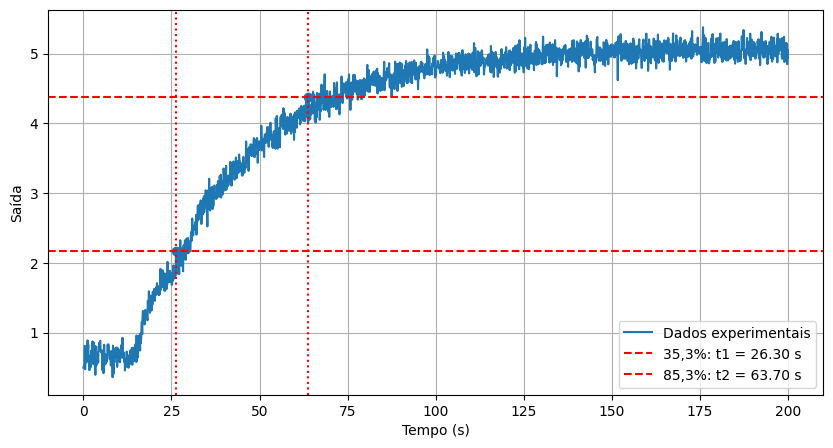

In [39]:
plt.figure(figsize=(10,5))

plt.plot(t, saida, label='Dados experimentais')

plt.axhline(y_t1_sun, linestyle='--',
            label=f'35,3%: t1 = {t1_sun:.2f} s',c='r')

plt.axhline(y_t2_sun, linestyle='--',
            label=f'85,3%: t2 = {t2_sun:.2f} s',c='r')

plt.axvline(t1_sun, linestyle=':',c='r')
plt.axvline(t2_sun, linestyle=':',c='r')

plt.scatter([t1_sun, t2_sun], [y_t1_sun, y_t2_sun])

plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.grid()
plt.legend()
plt.show()

### Resposta estimada pelo método de Smith

In [40]:
saida_smith = np.zeros_like(t, dtype=float)

for i in range(len(t)):
    if t[i] < theta:
        saida_smith[i] = y0
    else:
        saida_smith[i] = y0 + K * delta_u * (1 - np.exp(-(t[i] - theta) / tau))

### Resposta estimada pelo método de Sundaresan

In [41]:
saida_sundaresan = np.zeros_like(t, dtype=float)

for i in range(len(t)):
    if t[i] < theta_sun:
        saida_sundaresan[i] = y0
    else:
        saida_sundaresan[i] = y0 + K * delta_u * (1 - np.exp(-(t[i] - theta_sun) / tau_sun))

### Comparação dos métodos de identificação


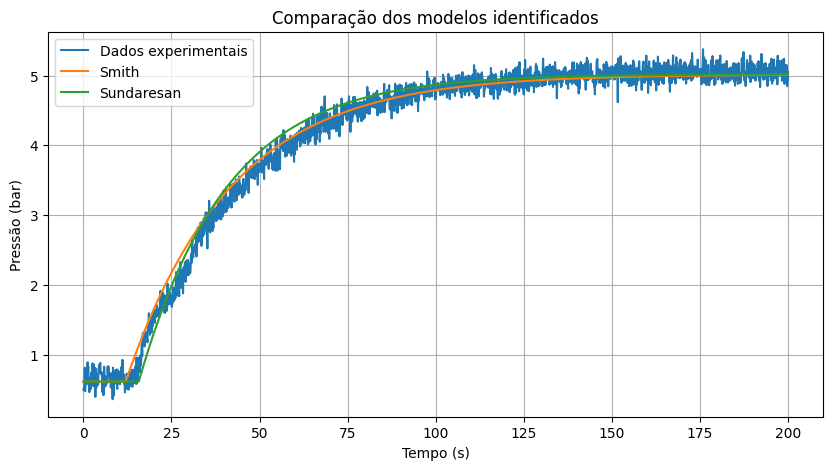

In [42]:

plt.figure(figsize=(10, 5))

plt.plot(t, saida, label='Dados experimentais')

plt.plot(t, saida_smith, label='Smith')

plt.plot(t,saida_sundaresan, label='Sundaresan')

plt.xlabel('Tempo (s)')
plt.ylabel('Pressão (bar)')
plt.title('Comparação dos modelos identificados')

plt.grid()
plt.legend()

plt.show()

### Cálculo do RMSE

In [43]:
rmse_smith = np.sqrt(np.mean((saida - saida_smith) ** 2))

rmse_sundaresan = np.sqrt(np.mean((saida - saida_sundaresan) ** 2))

print("RMSE Smith:", rmse_smith)
print("RMSE Sundaresan:", rmse_sundaresan)

RMSE Smith: 0.14722527590806803
RMSE Sundaresan: 0.15869647925131977


### Função de Transferência

Portanto, escolheremos o método de Smith já que resulta em um RMSE menor. Assim, usaremos os valores

K = 0,088

tau = 29,7

theta = 12

A função de transferência será do tipo FOPDT (First Order Plus Dead Time):


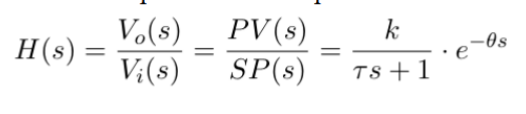

In [44]:
# Em python, precisamos usar a aproximação de Padé para o atraso

G = ct.tf([K], [tau, 1])
num_delay, den_delay = ct.pade(theta, 1) # Aproximação de Padé de 1° ordem do atraso
Delay = ct.tf(num_delay, den_delay)

# Modelo completo
H = G * Delay

print(H)

<TransferFunction>: sys[32]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     -0.08814 s + 0.01469
  --------------------------
  29.7 s^2 + 5.95 s + 0.1667


### Respostas em malha aberta e malha fechada

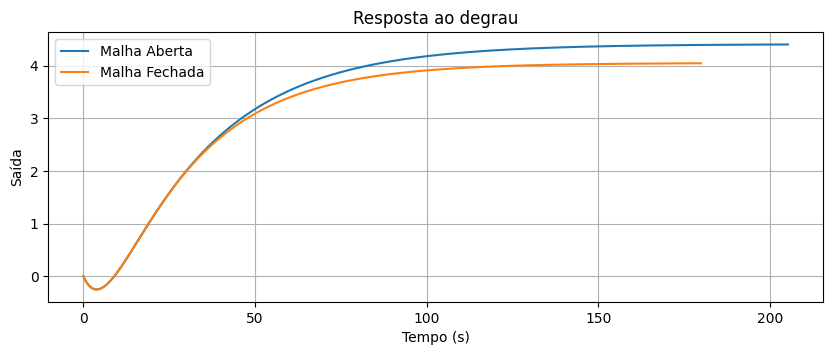

In [48]:
t_ma, y_ma = ct.step_response(H) # set point 50 do degrau
y_ma *= 50

T = ct.feedback(H, 1)
t_mf, y_mf = ct.step_response(T)
y_mf *= 50

plt.figure(figsize=(10,3.5))

plt.plot(t_ma, y_ma, label='Malha Aberta')
plt.plot(t_mf, y_mf, label = 'Malha Fechada')

plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.title('Resposta ao degrau')
plt.legend()
plt.grid()
plt.show()
# y_ma = y0 + delta_u * y_ma

tempo de subida - tr (intervalo necessário para que a amplitude varie de 10% a 90% do Valor Final)

tempo de acomodação  - ts (intervalo para o regime estacionário)

In [46]:
info_ma = ct.step_info(H)
info_mf = ct.step_info(T)

print("Malha aberta")
print(info_ma)

print("\nMalha fechada")
print(info_mf)

Malha aberta
{'RiseTime': 67.00801159131989, 'SettlingTime': 129.05246676846792, 'SettlingMin': 0.07948268786972268, 'SettlingMax': 0.08814492968715426, 'Overshoot': 0.0, 'Undershoot': 5.637755183981256, 'Peak': 0.08801215441332112, 'PeakTime': 205.1603317857695, 'SteadyStateValue': 0.08814492968715426}

Malha fechada
{'RiseTime': 59.06976815393883, 'SettlingTime': 114.66484406352832, 'SettlingMin': 0.0730372781043458, 'SettlingMax': 0.0810047699367549, 'Overshoot': 0.0, 'Undershoot': 6.1482330110344146, 'Peak': 0.0808733267235856, 'PeakTime': 179.8153236450785, 'SteadyStateValue': 0.0810047699367549}


O tempo de subida do sistema em malha aberta é mais alto. Além disso, seu tempo de acomodação também é superior. Logo, podemos perceber que a realimentação deixa a resposta do sistema mais rápida.  

In [55]:
# Erros em malha aberta e malha fechada sem controlador 
# set point do degrau (50) menos o valor que estabiliza
erro_processo_ma = 50 - np.mean(y_ma[-20:])
erro_processo_mf = 50 - np.mean(y_mf[-20:])
print("Malha aberta")
print(erro_processo_ma)
print("\nMalha fechada")
print(erro_processo_mf)

Malha aberta
45.601515324406215

Malha fechada
45.958953292181256
